<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/FP-Growth%20Algorithm%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!

First 5 rows:
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation

Dataset shape:
(134, 2)


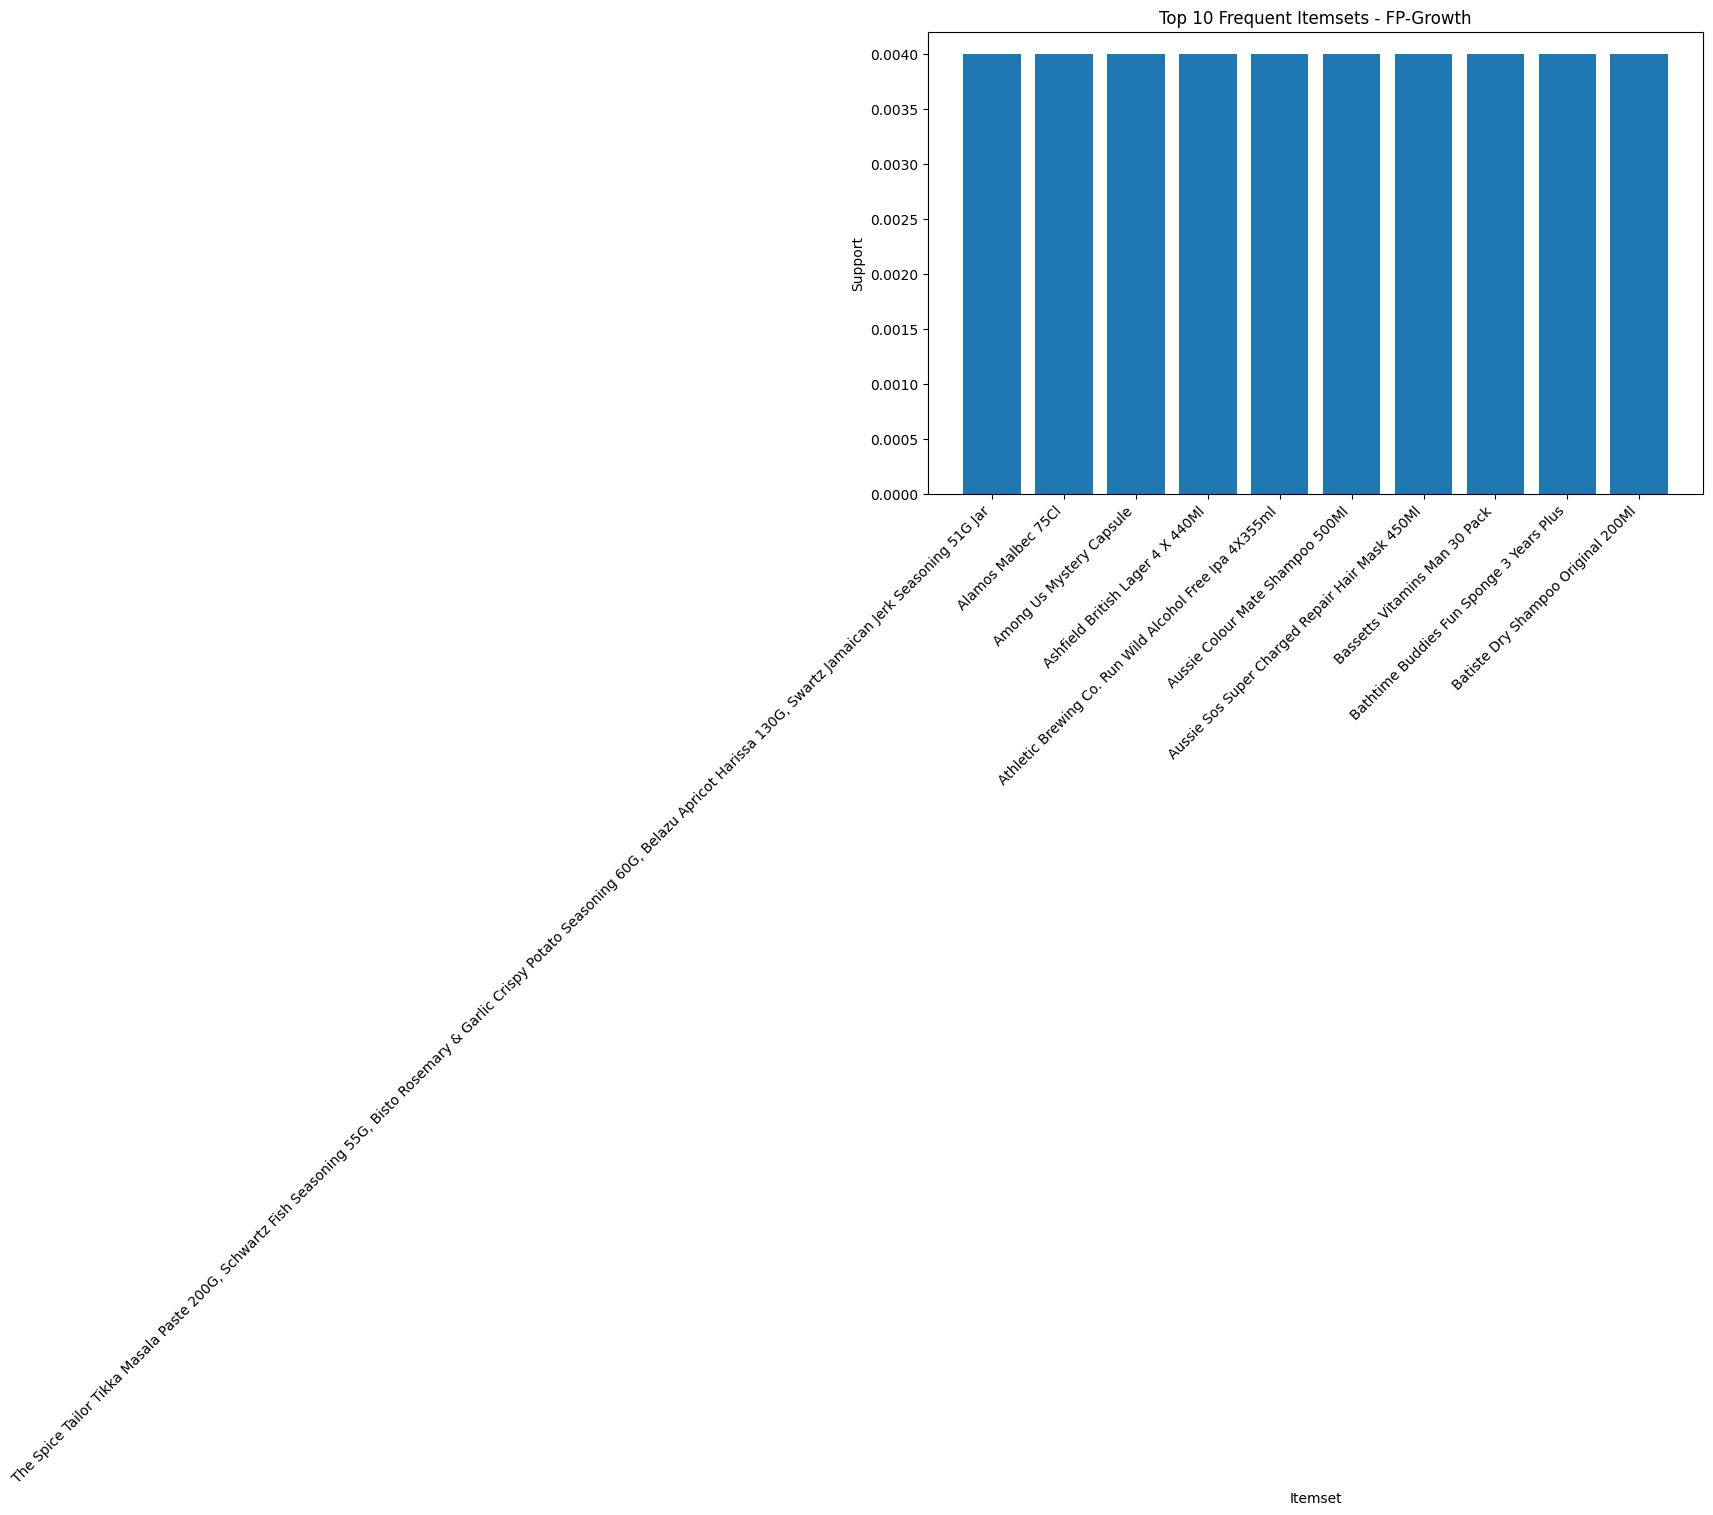

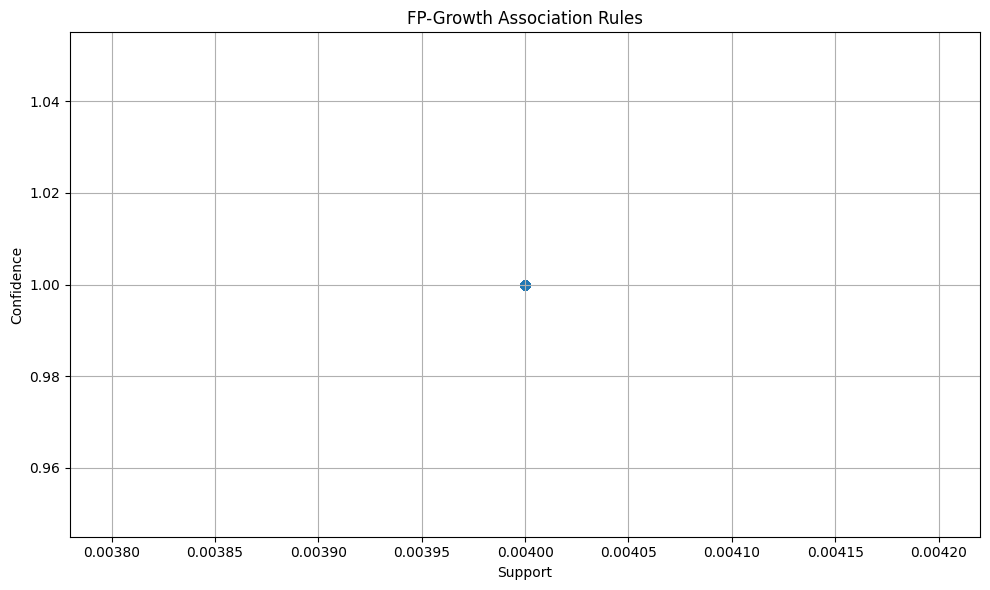

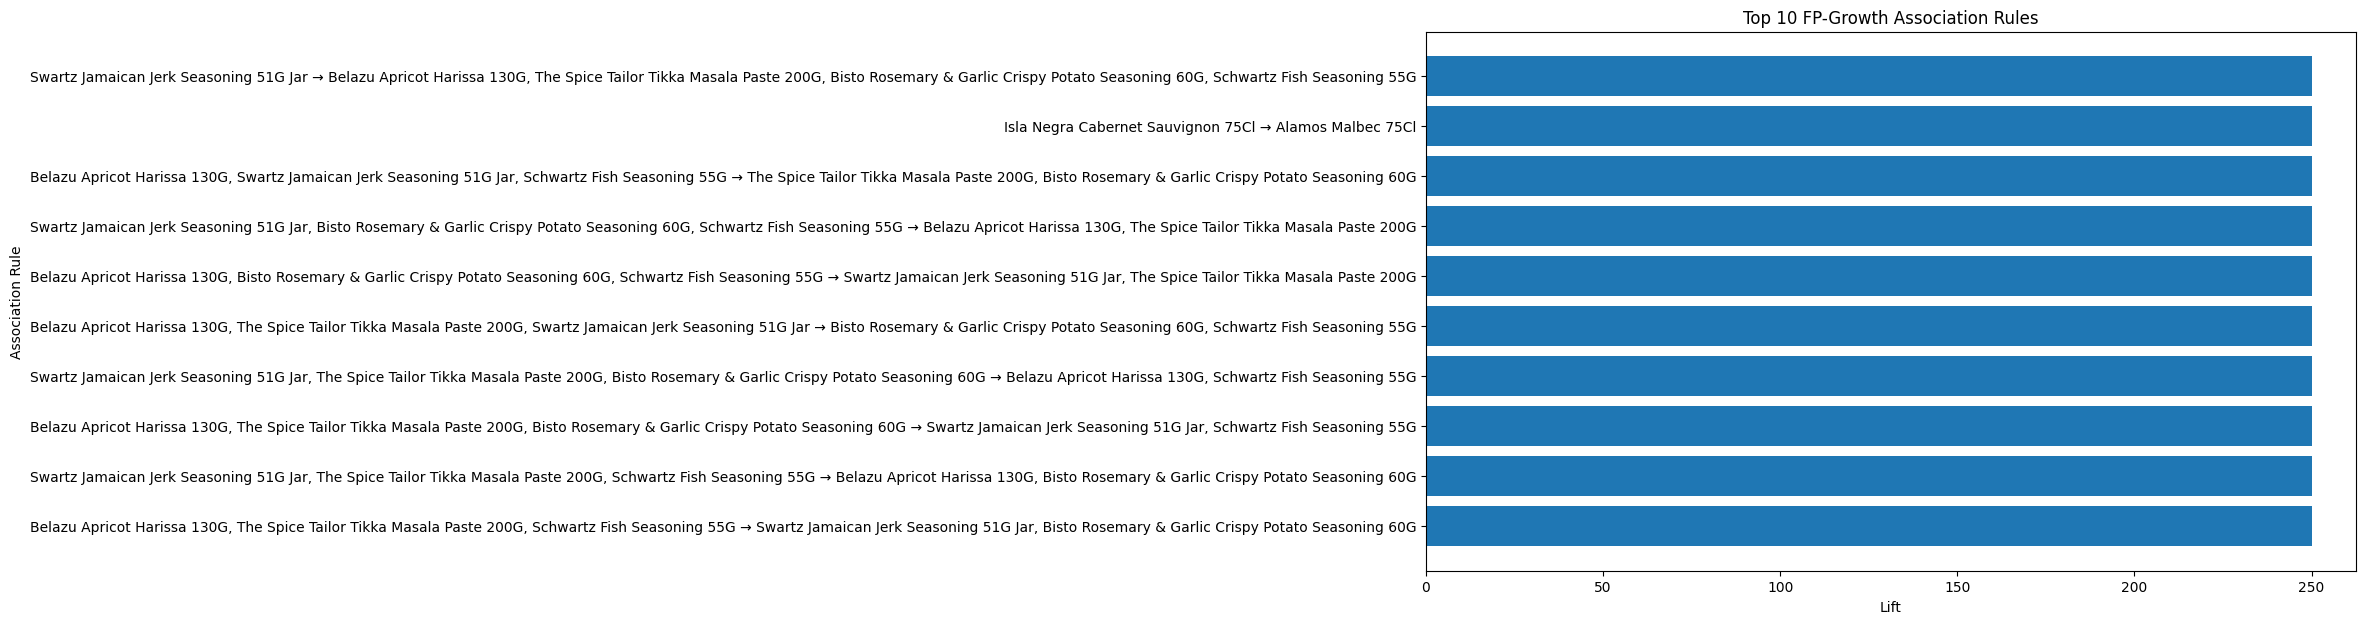

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("/content/aisles.csv")

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)


# ============================================
# 2. CREATE TRANSACTIONS
# ============================================
# The 'aisles.csv' dataset contains only 'aisle_id' and 'aisle' columns.
# It is a lookup table for aisle names and does not contain transactional data
# (e.g., customer purchases with multiple items). Therefore, it cannot be used
# directly for association rule mining in the traditional sense, which requires
# a list of items per transaction (e.g., items in a shopping basket).

# The following code block is commented out as it requires 'Member_number', 'Date',
# and 'itemDescription' columns, which are not present in 'aisles.csv'.

# transactions = (
#     df.groupby(
#         ["Member_number", "Date"]
#     )["itemDescription"]
#     .apply(list)
#     .values
# )

# print("\nNumber of transactions:",
#       len(transactions))


# ============================================
# 3. TRANSACTION ENCODING
# ============================================

# encoder = TransactionEncoder()

# encoded_data = encoder.fit(
#     transactions
# ).transform(transactions)

# basket = pd.DataFrame(
#     encoded_data,
#     columns=encoder.columns_
# )

# print("\nEncoded transaction data:")
# print(basket.head())


# ============================================
# 4. FP-GROWTH ALGORITHM
# ============================================

# frequent_itemsets = fpgrowth(
#     basket,
#     min_support=0.01,
#     use_colnames=True
# )


# ============================================
# 5. DISPLAY FREQUENT ITEMSETS
# ============================================

# print("\n================================")
# print("FREQUENT ITEMSETS")
# print("================================")

# print(
#     frequent_itemsets.sort_values(
#         by="support",
#         ascending=False
#     ).head(20)
# )


# ============================================
# 6. ASSOCIATION RULES
# ============================================

# rules = association_rules(
#     frequent_itemsets,
#     metric="confidence",
#     min_threshold=0.2
# )


# ============================================
# 7. DISPLAY ASSOCIATION RULES
# ============================================

# print("\n================================")
# print("ASSOCIATION RULES")
# print("================================")

# print(
#     rules[
#         [
#             "antecedents",
#             "consequents",
#             "support",
#             "confidence",
#             "lift"
#         ]
#     ].sort_values(
#         by="lift",
#         ascending=False
#     ).head(20)
# )


# ============================================
# 8. TOP 10 FREQUENT ITEMSETS
# ============================================

top_items = (
    frequent_itemsets
    .sort_values(
        by="support",
        ascending=False
    )
    .head(10)
    .copy()
)

top_items["item"] = (
    top_items["itemsets"]
    .apply(
        lambda x: ", ".join(x)
    )
)


# ============================================
# 9. GRAPH 1
# TOP 10 FREQUENT ITEMSETS
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    top_items["item"],
    top_items["support"]
)

plt.xlabel("Itemset")
plt.ylabel("Support")

plt.title(
    "Top 10 Frequent Itemsets - FP-Growth"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================
# 10. GRAPH 2
# SUPPORT VS CONFIDENCE
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    rules["support"],
    rules["confidence"]
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.title(
    "FP-Growth Association Rules"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================
# 11. GRAPH 3
# TOP RULES BY LIFT
# ============================================

top_rules = (
    rules
    .sort_values(
        by="lift",
        ascending=False
    )
    .head(10)
    .copy()
)

rule_names = []

for _, row in top_rules.iterrows():

    antecedent = ", ".join(
        row["antecedents"]
    )

    consequent = ", ".join(
        row["consequents"]
    )

    rule_names.append(
        antecedent +
        " → " +
        consequent
    )


plt.figure(figsize=(12, 7))

plt.barh(
    rule_names,
    top_rules["lift"]
)

plt.xlabel("Lift")

plt.ylabel("Association Rule")

plt.title(
    "Top 10 FP-Growth Association Rules"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()